Visualisation évolution indices notaires-insee immobiliers

Télécharger données xlsx du lien reçu par mail

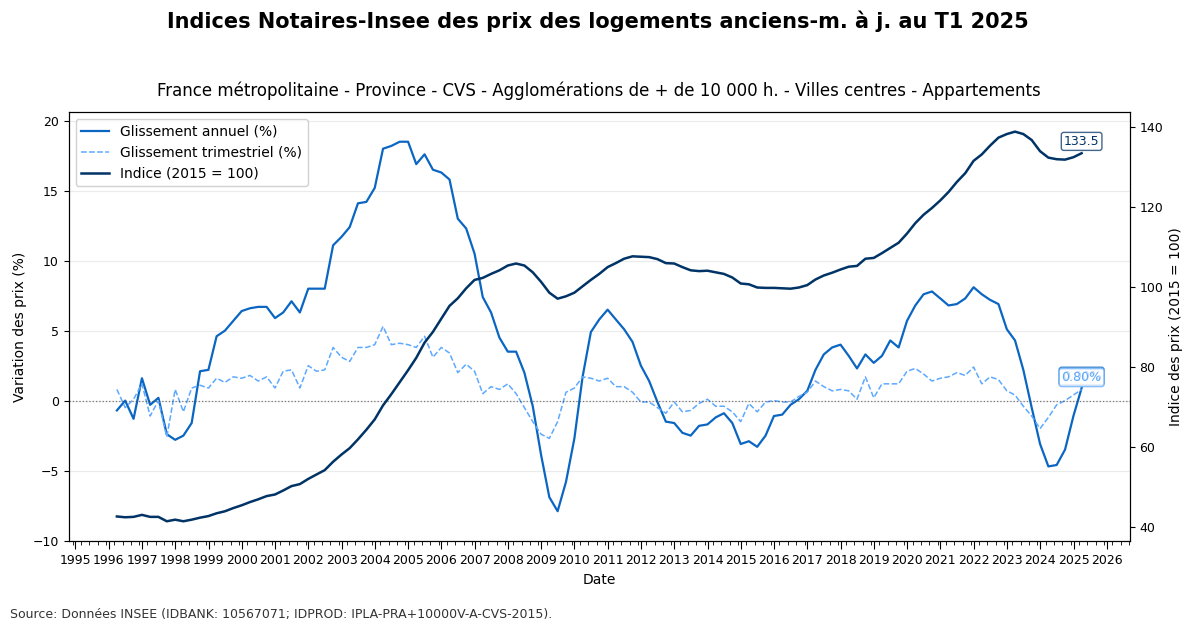

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import re

# --------------------------------------------------------------------
# 0. File + series identifiers
# --------------------------------------------------------------------
XLS_PATH = r"C:\Users\GODLEWSKI\Downloads\sl-IPLA.xlsx"   # adapt to your path, e.g. r"C:\...\sl_IPLA.xlsx"

IDBANK_TARGET = "010567071"              
IDPROD_TARGET = "IPLA-PRA+10000V-A-CVS-2015"


# --------------------------------------------------------------------
# 1. Helper: extract one quarterly series from a sheet by IDPROD/IDBANK
# --------------------------------------------------------------------
def extract_quarter_series_by_idprod(df, idprod, idbank=None):
    """
    From an INSEE 'IPLA' sheet (Indices / Glissements annuels / trimestriels),
    extract the time series for a given IDPROD (and optionally IDBANK).

    Returns a pandas Series indexed by quarter-end Timestamp.
    """
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    # filter by IDPROD (and IDBANK if given, as a safety check)
    mask = df["IDPROD"] == idprod
    if idbank is not None:
        mask &= df["IDBANK"].astype(str).str.strip() == str(idbank)

    row = df.loc[mask]
    if row.empty:
        raise KeyError(f"Series {idprod} (idbank={idbank}) not found in this sheet")
    row = row.iloc[0]

    # quarter columns look like: 'T1 1996', 'T3 2025 (p)', etc.
    qcols = []
    q_list = []
    y_list = []
    for c in df.columns:
        m = re.search(r"^T([1-4])\s+(\d{4})", c)
        if m:
            qcols.append(c)
            q_list.append(m.group(1))   # '1'..'4'
            y_list.append(m.group(2))   # '1996'...

    values = []
    dates = []
    for c, q, y in zip(qcols, q_list, y_list):
        v = row[c]
        if pd.isna(v):
            continue
        year = int(y)
        month = {"1": 3, "2": 6, "3": 9, "4": 12}[q]  # quarter-end months
        date = pd.Timestamp(year, month, 1) + pd.offsets.MonthEnd(0)
        dates.append(date)
        values.append(float(v))

    s = pd.Series(values, index=dates).sort_index()
    return s


# --------------------------------------------------------------------
# 2. Load the 3 relevant sheets (skip Volumes)
# --------------------------------------------------------------------
xls = pd.ExcelFile(XLS_PATH)

indices_df = pd.read_excel(xls, sheet_name="Indices_v4")
ga_df      = pd.read_excel(xls, sheet_name="Glissements annuels_v4")
gt_df      = pd.read_excel(xls, sheet_name="Glissements trimestriels_v4")


# --------------------------------------------------------------------
# 3. Extract IPLA-FM-A-CVS-2015 from each sheet
# --------------------------------------------------------------------
# Level index (2015=100)
idx_cvs = extract_quarter_series_by_idprod(
    indices_df, IDPROD_TARGET, IDBANK_TARGET
)

# Glissement annuel (%)
ga_cvs = extract_quarter_series_by_idprod(
    ga_df, IDPROD_TARGET, IDBANK_TARGET
)

# Glissement trimestriel (%)
gt_cvs = extract_quarter_series_by_idprod(
    gt_df, IDPROD_TARGET, IDBANK_TARGET
)


# --------------------------------------------------------------------
# 4. Combine into a single quarterly DataFrame
# --------------------------------------------------------------------
df_cvs = pd.concat(
    [
        idx_cvs.rename("index_cvs"),
        ga_cvs.rename("ga_cvs"),
        gt_cvs.rename("gt_cvs"),
    ],
    axis=1,
).sort_index()

# Optional: restrict period (e.g. from 1996 onwards)
df_plot = df_cvs[df_cvs.index >= "1996-01-01"].copy()



# --------------------------------------------------------------------
# 5. Friggit-type graphic (enhanced & self-contained) with yearly x-axis ticks
# --------------------------------------------------------------------
import matplotlib.dates as mdates

fig, ax_left = plt.subplots(figsize=(12, 6.5))

# Colors
COLOR_ANNUAL = "#0A66C2"        # blue
COLOR_QTR    = "#5DA9FF"        # light blue
COLOR_INDEX  = "#003366"        # dark blue

# Left axis: % changes
ax_left.plot(
    df_plot.index,
    df_plot["ga_cvs"],
    label="Glissement annuel (%)",
    linewidth=1.6,
    color=COLOR_ANNUAL,
)
ax_left.plot(
    df_plot.index,
    df_plot["gt_cvs"],
    label="Glissement trimestriel (%)",
    linewidth=1.1,
    linestyle="--",
    color=COLOR_QTR,
)

# Zero line
ax_left.axhline(0, linewidth=0.9, linestyle=":", alpha=0.7, color="#444")

ax_left.set_xlabel("Date")
ax_left.set_ylabel("Variation des prix (%)")
ax_left.grid(axis="y", alpha=0.25)
ax_left.set_axisbelow(True)

# Right axis: level
ax_right = ax_left.twinx()
ax_right.plot(
    df_plot.index,
    df_plot["index_cvs"],
    label="Indice (2015 = 100)",
    linewidth=1.8,
    color=COLOR_INDEX,
)

ax_right.set_ylabel("Indice des prix (2015 = 100)")

# ---------- NEW: Yearly ticks ----------
# Major ticks: one per year, labeled with year.
ax_left.xaxis.set_major_locator(mdates.YearLocator())
ax_left.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# Minor ticks: quarterly (Mar, Jun, Sep, Dec) for visual reference.
ax_left.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[3,6,9,12]))
ax_left.tick_params(axis='x', which='major', length=6)
ax_left.tick_params(axis='x', which='minor', length=3, labelsize=0)  # hide minor labels

# Legend: combine
lines_l, labels_l = ax_left.get_legend_handles_labels()
lines_r, labels_r = ax_right.get_legend_handles_labels()
legend = ax_left.legend(
    lines_l + lines_r,
    labels_l + labels_r,
    loc="upper left",
    frameon=True,
    framealpha=0.9
)
for text in legend.get_texts():
    text.set_fontsize(10)

# Title, subtitle, note
fig.suptitle(
    "Indices Notaires‑Insee des prix des logements anciens‑m. à j. au T1 2025",
    fontsize=15,
    fontweight="bold",
    y=0.95
)
ax_left.set_title(
    "France métropolitaine - Province - CVS - Agglomérations de + de 10 000 h. - Villes centres - Appartements",
    fontsize=12,
    pad=12
)

note_text = (
    "Source: Données INSEE (IDBANK: 10567071; IDPROD: IPLA-PRA+10000V-A-CVS-2015)."
)
fig.text(
    0.01,
    0.01,
    note_text,
    fontsize=9,
    color="#333",
    ha="left",
    va="bottom"
)

# Annotate last available values
last_date = df_plot.index[-1]
last_ga = df_plot.loc[last_date, "ga_cvs"]
last_gt = df_plot.loc[last_date, "gt_cvs"]
last_idx = df_plot.loc[last_date, "index_cvs"]

def _annot(ax, x, y, txt, color):
    ax.annotate(
        txt,
        xy=(x, y),
        xytext=(0, 6),
        textcoords="offset points",
        fontsize=9,
        color=color,
        ha="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.75)
    )

_annot(ax_left, last_date, last_ga, f"{last_ga:.2f}%", COLOR_ANNUAL)
_annot(ax_left, last_date, last_gt, f"{last_gt:.2f}%", COLOR_QTR)
_annot(ax_right, last_date, last_idx, f"{last_idx:.1f}", COLOR_INDEX)

# Improve tick formatting
ax_left.tick_params(axis="both", labelsize=9)
ax_right.tick_params(axis="y", labelsize=9)

# Reduce clutter: limit y-range left if extreme outliers absent
ga_min = df_plot["ga_cvs"].min()
ga_max = df_plot["ga_cvs"].max()
pad = (ga_max - ga_min) * 0.08 if ga_max != ga_min else 1
ax_left.set_ylim(ga_min - pad, ga_max + pad)

ax_right.grid(False)

fig.tight_layout(rect=(0, 0.04, 1, 0.92))
plt.show()